## 1. Configuración del entorno
Cargamos las paqueterías necesarias.

In [1]:
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle

**Montamos y configuramos el entorno**

In [ ]:
# Conectamos el colab con nuestro drive
from google.colab import drive
drive.mount('/content/drive')

# Ruta a la carpeta del proyecto en Drive
PROJECT = '/content/drive/MyDrive/proyecto-auto-mpg'
sys.path.insert(0, PROJECT)

# Seed global fijo para la reproducibilidad
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Drive montado y entorno listo")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado y entorno listo


## 2. Carga del dataset
**Cargaremos el dataset tal y como nos recomienda la página del dataset.**

In [ ]:
!pip install -q ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

auto_mpg = fetch_ucirepo(id=9)

X = auto_mpg.data.features
y = auto_mpg.data.targets

print(auto_mpg.variables[['name', 'role', 'type']])

           name     role         type
0  displacement  Feature   Continuous
1           mpg   Target   Continuous
2     cylinders  Feature      Integer
3    horsepower  Feature   Continuous
4        weight  Feature   Continuous
5  acceleration  Feature   Continuous
6    model_year  Feature      Integer
7        origin  Feature      Integer
8      car_name       ID  Categorical


**Armamos el DataFrame de trabajo.**

In [ ]:
df = X.copy()
df['mpg'] = y['mpg'].values

# car_name separado solo para EDA
car_names = auto_mpg.data.ids

print(f"Shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")
df.head()

Shape: (398, 8)
Columnas: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'mpg']


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0


In [ ]:
print("Columnas en X (features):")
print(X.columns.tolist())

print("\nColumnas en y (targets):")
print(y.columns.tolist())

Columnas en X (features):
['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']

Columnas en y (targets):
['mpg']


Vemos que el `mpg` funciona como `target`, mientras que la columna `car_names` funciona como `ID`

## 3. Revisión inicial del dataset

In [ ]:
print(" Dimensiones ")
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")

print("Tipos de datos")
print(df.dtypes)

print("Valores nulos por colmna")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Sin valores nulos")
print(f"Total nulos: {nulos.sum()}")

print("Estadísticas descriptivas")
df.describe().round(2)

 Dimensiones 
Filas: 398  |  Columnas: 8
Tipos de datos
displacement    float64
cylinders         int64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
mpg             float64
dtype: object
Valores nulos por colmna
horsepower    6
dtype: int64
Total nulos: 6
Estadísticas descriptivas


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,398.00,398.00,392.00,398.00,398.00,398.00,398.00,398.00
mean,193.43,5.45,104.47,2970.42,15.57,76.01,1.57,23.51
std,104.27,1.70,38.49,846.84,2.76,3.70,0.80,7.82
min,68.00,3.00,46.00,1613.00,8.00,70.00,1.00,9.00
25%,104.25,4.00,75.00,2223.75,13.82,73.00,1.00,17.50
50%,148.50,4.00,93.50,2803.50,15.50,76.00,1.00,23.00
75%,262.00,8.00,126.00,3608.00,17.18,79.00,2.00,29.00
max,455.00,8.00,230.00,5140.00,24.80,82.00,3.00,46.60


Notamos que:

* La variable `origin` tiene valores como 1, 2, 3, está codificada numéricamente pero representa categorías (USA, Europa, Japón).
* `horsepower` tiene 6 valores nulos que deberán ser tratados antes del modelado.
* Las variables tienen rangos muy distintos (`weight` va de 1613 a 5140, `model_year` de 70 a 82), lo que hace necesario el escalado para los modelos lineales.

## 4. Preprocesamiento

### 4.1 Tratamiento de valores nulos en `horsepower`

Se imputarán los 6 valores nulos de `horsepower` con la mediana en lugar de la media, dado que la variable presenta una distribución asimétrica positiva con outliers en el rango superior. La mediana es un estimador más robusto en este contexto porque no se ve afectada por los valores extremos que sesgan la media hacia arriba.

In [ ]:
media   = df['horsepower'].mean()
mediana = df['horsepower'].median()

print(f"Media:      {media:.1f} HP")
print(f"Mediana:    {mediana:.1f} HP")
print(f"Diferencia: {abs(media - mediana):.1f} HP")

autos_extremos = (df['horsepower'] > 150).sum()
print(f"Autos con más de 150 HP (jalan la media): {autos_extremos}")

Media:      104.5 HP
Mediana:    93.5 HP
Diferencia: 11.0 HP
Autos con más de 150 HP (jalan la media): 45


In [ ]:
print(f"Nulos antes:  {df['horsepower'].isnull().sum()}")
mediana = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(mediana)
print(f"Nulos después: {df['horsepower'].isnull().sum()}")
print(f"Mediana usada: {mediana:.1f}")

# Verificar que no queda ningún nulo en todo el DataFrame
print(f"Total nulos en el dataset: {df.isnull().sum().sum()}")

Nulos antes:  6
Nulos después: 0
Mediana usada: 93.5
Total nulos en el dataset: 0


### 4.2 Codificación de la variable `origin`

* `origin` tiene 3 categorías: 1=USA, 2=Europa, 3=Japón.

* Utilizaremos `get_dummies` con `drop_first=True` para convertir en columnas binarias:

    Si `origin_2=0` y `origin_3=0` → el auto es de USA

    Si `origin_2=1` → el auto es de Europa

    Si `origin_3=1` → el auto es de Japón

In [ ]:
print("Valores únicos de origin antes:", df['origin'].unique())
print("Distribución:")
print(df['origin'].value_counts())

df = pd.get_dummies(df, columns=['origin'], drop_first=True, dtype=int)

print(f"\nColumnas después del encoding:")
print(list(df.columns))

Valores únicos de origin antes: [1 3 2]
Distribución:
origin
1    249
3     79
2     70
Name: count, dtype: int64

Columnas después del encoding:
['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'mpg', 'origin_2', 'origin_3']


La variable `origin` fue codificada mediante one-hot encoding con `drop_first=True`, generando dos variables dummy (`origin_2` para Europa y `origin_3` para Japón). La categoría de referencia USA se infiere implícitamente cuando ambas variables valen cero, evitando así la trampa de la variable dummy que introduciría multicolinealidad perfecta en los modelos lineales.

## 5. Análisis Exploratorio de Datos (EDA)
**Observaremos algunas gráficas para ver la forma de los datos y correlaciones existentes.**

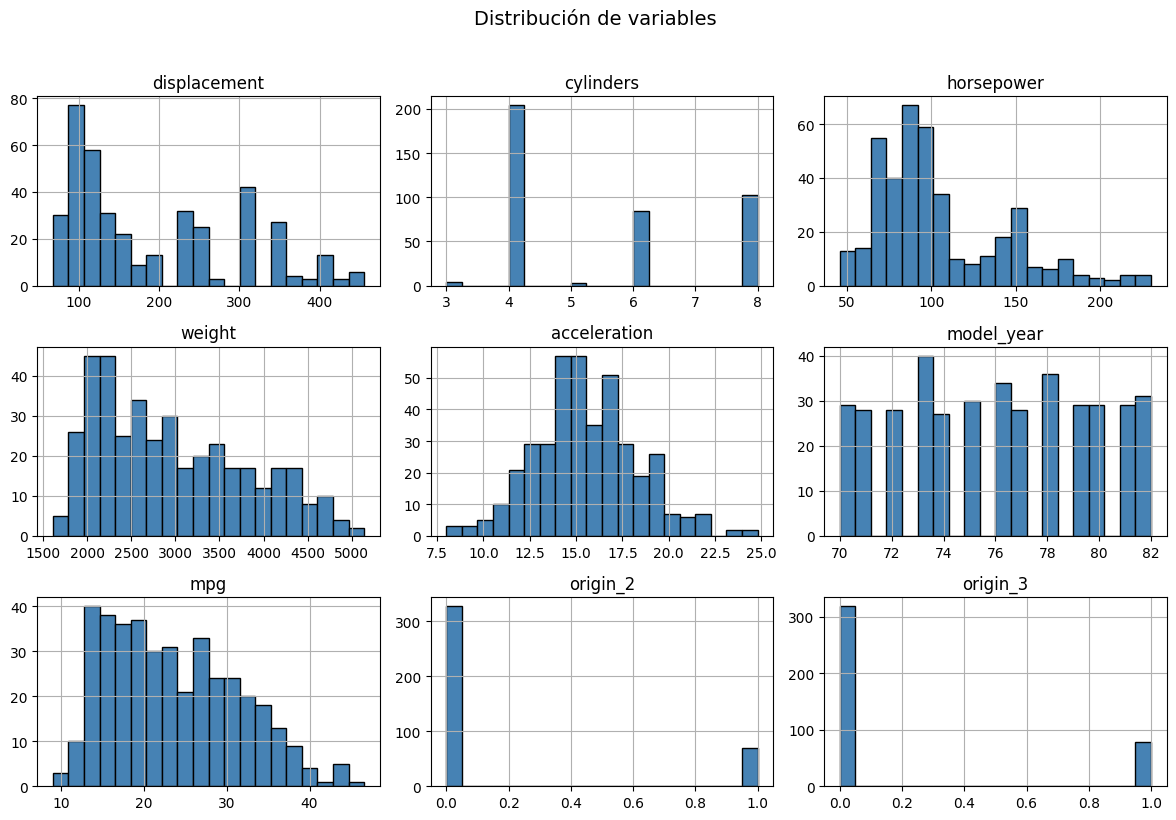

Guardado en figures/histogramas.png


In [ ]:
df.hist(figsize=(12, 8), bins=20, edgecolor='black', color='steelblue')
plt.suptitle('Distribución de variables', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(f'{PROJECT}/figures/histogramas.png', bbox_inches='tight')
plt.show()
print("Guardado en figures/histogramas.png")

**Observaciones de los histogramas:**

* `mpg` presenta sesgo positivo (cola hacia la derecha), la mayoría de autos rinde entre 15 y 30 MPG, con pocos autos muy eficientes por encima de 35.

* `cylinders` solo toma valores discretos (3, 4, 5, 6, 8), se comporta más como una variable ordinal que continua. La mayoría de autos tiene 4 cilindros.

* `displacement`, `horsepower` y `weight` también muestran sesgo positivo con colas largas hacia la derecha, lo que indica la presencia de valores atípicos en el rango superior.

* `model_year` tiene distribución relativamente uniforme entre 70 y 82, representando autos fabricados de 1970 a 1982.

* `origin_1`y `origin_2` muestran que la mayoría de autos provienen del origen 1 (USA).

Vemos la distribución específica del MPG.

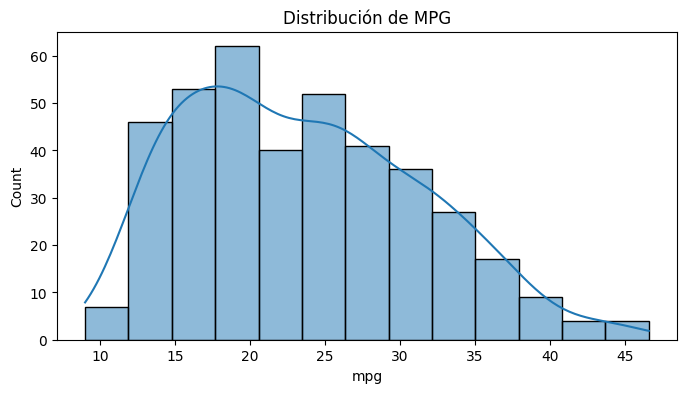

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df["mpg"], kde=True)
plt.title("Distribución de MPG")

plt.show()

Veremos la relación de las variables más correlacionadas con `mpg` mediante scatter plots.

<Axes: xlabel='weight', ylabel='mpg'>

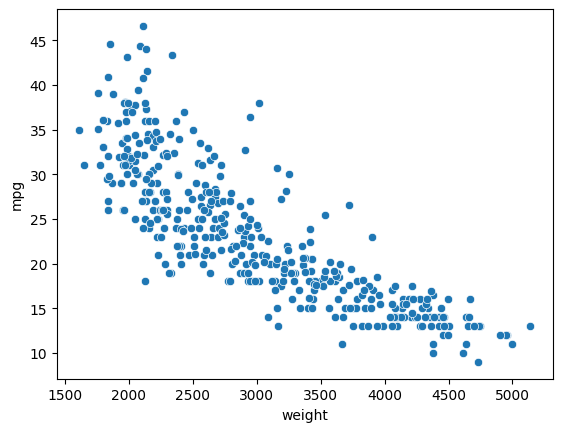

In [ ]:
sns.scatterplot(
    data=df,
    x="weight",
    y="mpg"
)


<Axes: xlabel='horsepower', ylabel='mpg'>

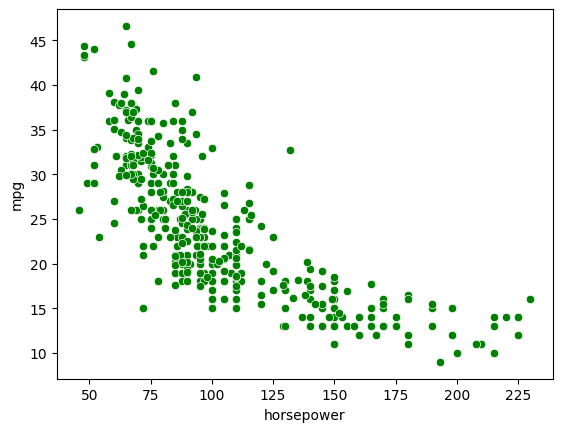

In [ ]:
sns.scatterplot(
    data=df,
    x="horsepower",
    y="mpg",
    color='green'
)


<Axes: xlabel='displacement', ylabel='mpg'>

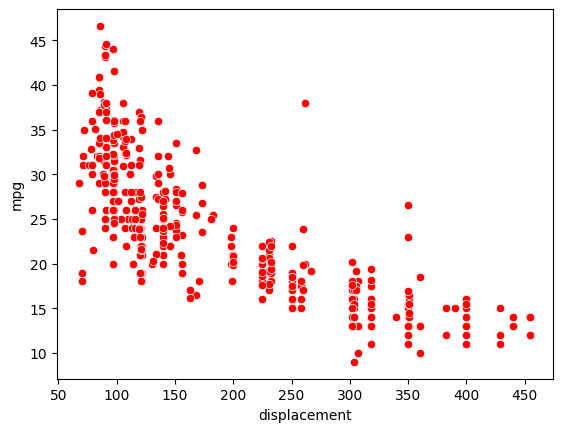

In [ ]:
sns.scatterplot(
    data=df,
    x="displacement",
    y="mpg",
    color='red'
)


**Realizaremos un boxplot para detectar outliers.**

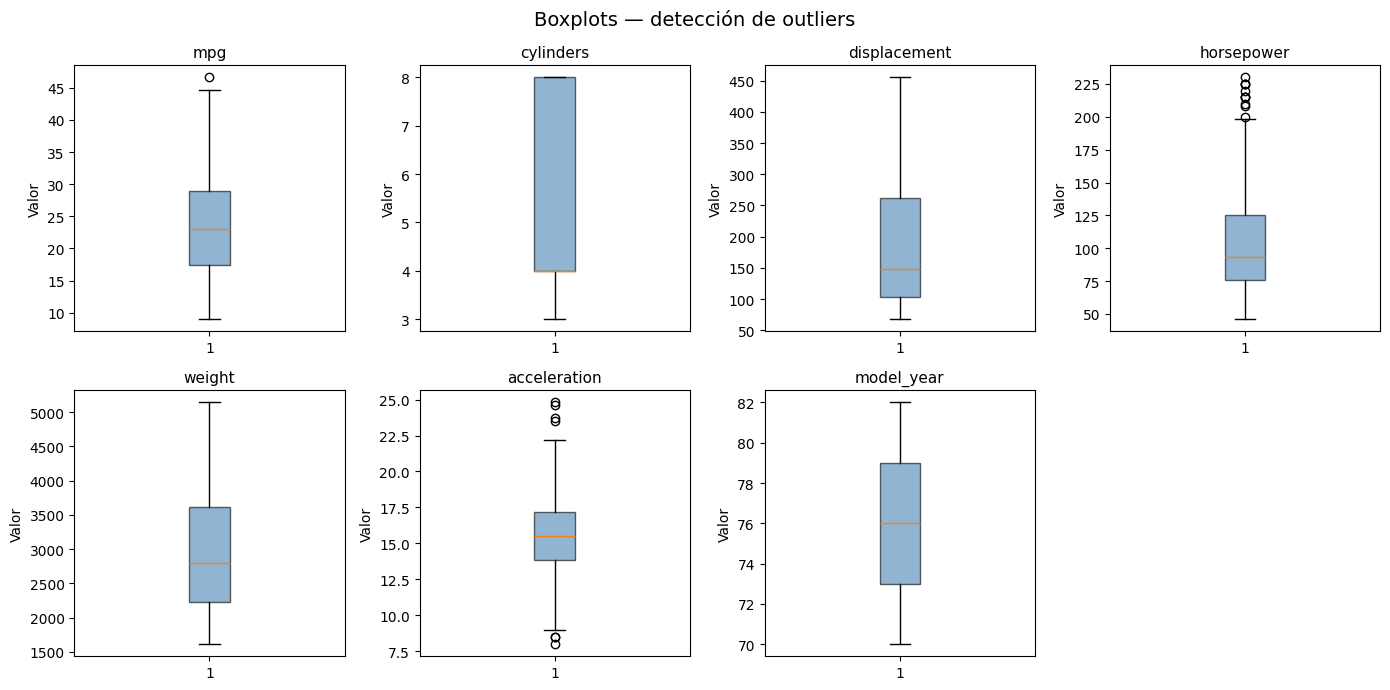

In [ ]:
columnas = ['mpg', 'cylinders', 'displacement', 'horsepower',
            'weight', 'acceleration', 'model_year']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(columnas):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Valor')

axes[-1].set_visible(False)

plt.suptitle('Boxplots — detección de outliers', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PROJECT}/figures/boxplots.png', bbox_inches='tight')
plt.show()

**Observaciones de los boxplots:**

* `horsepower` y `acceleration` presentan outliers visibles fuera de los bigotes superiores e inferiores respectivamente.

* `mpg` también muestra valores atípicos en el rango superior (autos muy eficientes).


**Veremos las correlaciones existentes entre las variables.**

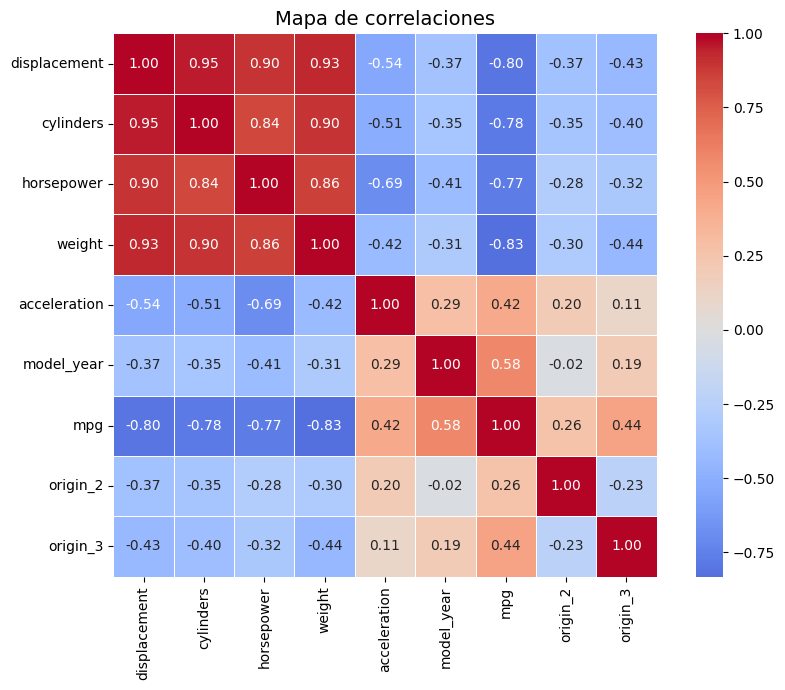

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Mapa de correlaciones', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PROJECT}/figures/correlaciones.png', bbox_inches='tight')
plt.show()

**Observaciones del mapa de correlaciones:**

* `displacement`, `cylinders` y `weight` tienen correlación muy alta entre sí (>0.9), evidenciando **multicolinealidad severa**, las tres variables miden indirectamente el tamaño del motor.

* `mpg` tiene correlación negativa fuerte con `displacement` (-0.80), `cylinders` (-0.78) y `weight` (-0.83), es decir, más motor y más peso implica menor eficiencia.

* `model_year` tiene correlación positiva con `mpg` (+0.58) por lo que los autos fabricados en años más recientes son más eficientes.

* `acceleration` y `origin_1 ` y `origin_2` tienen las correlaciones más bajas con `mpg` (+0.42), lo que sugiere que seran las variables menos predictivas del conjunto.

## 6. División train/test
Realizamos el split 80/20 antes de cualquier escalado para evitar data leakage.

In [ ]:
features = [col for col in df.columns if col != 'mpg']
target   = 'mpg'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba:        {X_test.shape}")

Entrenamiento: (318, 8)
Prueba:        (80, 8)


### 6.1 Guardado de datos limpios sin escalar
Guardamos el dataset completo limpio y los splits en escala original. Estos archivos sirven para referencia, visualizaciones y modelos que no requieren escalado como Random Forest y XGBoost.

In [ ]:
# Dataset completo limpio sin escalar
df.to_csv(f'{PROJECT}/data/auto_mpg_clean.csv', index=False)
print(f"auto_mpg_clean.csv guardado | shape: {df.shape}")

# Train y test sin escalar
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

X_train_raw['mpg'] = y_train.values
X_test_raw['mpg']  = y_test.values

X_train_raw.to_csv(f'{PROJECT}/data/train_raw.csv', index=False)
X_test_raw.to_csv(f'{PROJECT}/data/test_raw.csv',   index=False)

print("train_raw.csv y test_raw.csv guardados")

auto_mpg_clean.csv guardado | shape: (398, 9)
train_raw.csv y test_raw.csv guardados


## 7. Escalado de variables

Notamos que cada variable vive en una escala completamente diferente.

En casos como Ridge, la penalización castiga más a `weight` que a `model_year` simplemente porque sus números son más grandes, no porque sea menos importante. El modelo tomaría decisiones basadas en la escala de los datos, no en su relevancia real.

In [ ]:
# Variables continuas — las únicas que deben escalarse
cols_escalar  = ['displacement', 'cylinders', 'horsepower',
                 'weight', 'acceleration', 'model_year']

# Variables binarias
cols_binarias = ['origin_2', 'origin_3']

# fit SOLO con train
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test_scaled[cols_escalar]  = scaler.transform(X_test[cols_escalar])

# Verificación
verificacion = pd.DataFrame(X_train_scaled[cols_escalar], columns=cols_escalar)
print("Verificación del escalado (medias ~0, std ~1):")
print(verificacion.agg(['mean', 'std']).round(3))

print("\nVariables binarias sin escalar (deben seguir en 0 y 1):")
print(X_train_scaled[cols_binarias].describe().loc[['min','max']])

Verificación del escalado (medias ~0, std ~1):
      displacement  cylinders  horsepower  weight  acceleration  model_year
mean        -0.000      0.000       0.000   0.000        -0.000      -0.000
std          1.002      1.002       1.002   1.002         1.002       1.002

Variables binarias sin escalar (deben seguir en 0 y 1):
     origin_2  origin_3
min       0.0       0.0
max       1.0       1.0


Todos los valores continuos son ahora comparables entre sí. Un valor de 2.0 en `weight` escalado significa lo mismo que 2.0 en `horsepower` escalado.

Se aplicó `StandardScaler` para estandarizar todas las variables predictoras.

### 7.1 Guardado de datos escalados
Guardamos los splits escalados y el scaler para uso en modelos lineales, MLP y la demo en vivo.

In [ ]:
# Train y test escalados
X_train_final = X_train_scaled.copy()
X_test_final  = X_test_scaled.copy()

X_train_final['mpg'] = y_train.values
X_test_final['mpg']  = y_test.values

X_train_final.to_csv(f'{PROJECT}/data/train_scaled.csv', index=False)
X_test_final.to_csv(f'{PROJECT}/data/test_scaled.csv',   index=False)

# Guardar scaler para la demo en vivo
with open(f'{PROJECT}/data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Verificar todos los archivos guardados
print("Archivos en data/:")
for a in sorted(os.listdir(f'{PROJECT}/data')):
    if not a.startswith('.'):
        print(f"  - {a}")

Archivos en data/:
  - auto_mpg_clean.csv
  - auto_mpg_clean.gsheet
  - scaler.pkl
  - test_raw.csv
  - test_scaled.csv
  - train_raw.csv
  - train_scaled.csv


**Resumen de archivos generados:**

| Archivo | Contenido | Para qué sirve |
|---|---|---|
| `auto_mpg_clean.csv` | 398 filas, escala original | Referencia y visualizaciones |
| `train_raw.csv` | 318 filas sin escalar | Random Forest, AdaBoost, XGBoost |
| `test_raw.csv` | 80 filas sin escalar | Evaluación de modelos de árboles |
| `train_scaled.csv` | 318 filas escaladas | GLM, Lasso, Ridge, MLP |
| `test_scaled.csv` | 80 filas escaladas | Evaluación de modelos lineales y MLP |
| `scaler.pkl` | Parámetros del scaler | Demo en vivo, datos nuevos |